In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# auto-detect environment — works in both Colab and VS Code
try:
    from google.colab import drive
    drive.mount('/content/drive')
    data_path = '/content/drive/MyDrive/ML/stock-lens/data/'
    print("running in Colab")
except ImportError:
    data_path = 'data/'
    print("running locally")

# installing pandas-ta before importing it
!pip install pandas_ta -q

import pandas_ta as ta

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
print("imports done")

running locally


ERROR: Ignored the following versions that require a different python version: 0.4.67b0 Requires-Python >=3.12; 0.4.71b0 Requires-Python >=3.12
ERROR: Could not find a version that satisfies the requirement pandas_ta (from versions: none)
ERROR: No matching distribution found for pandas_ta


ModuleNotFoundError: No module named 'pandas_ta'

In [ ]:
drive.mount('/content/drive', force_remount=False)

base_path = '/content/drive/MyDrive/ML/stock-lens/'
data_path = base_path + 'data/'

print("data path:", data_path)

Mounted at /content/drive
data path: /content/drive/MyDrive/ML/stock-lens/data/


In [ ]:
import gc

# loading prices with minimal memory footprint
prices = pd.read_csv(
    data_path + 'prices-split-adjusted.csv',
    parse_dates=['date'],
    usecols=['date', 'symbol', 'open', 'high', 'low', 'close', 'volume'],
    dtype={'open': 'float32', 'high': 'float32', 'low': 'float32',
           'close': 'float32', 'volume': 'float32'}
)
prices['symbol'] = prices['symbol'].astype('category')
prices = prices.sort_values(['symbol', 'date']).reset_index(drop=True)
print(f"prices loaded: {prices.shape} | {prices.memory_usage(deep=True).sum()/1e6:.1f} MB")

# loading only needed fundamental columns
fund_cols = ['Ticker Symbol', 'Period Ending', 'Earnings Per Share',
             'Total Revenue', 'Net Income', 'Total Assets',
             'Total Liabilities', 'Profit Margin', 'Total Equity',
             'Operating Margin', 'Current Ratio']
fundamentals = pd.read_csv(data_path + 'fundamentals.csv', usecols=fund_cols)
fundamentals.columns = [c.strip() for c in fundamentals.columns]
print(f"fundamentals loaded: {fundamentals.shape}")

# loading only needed securities columns
securities = pd.read_csv(data_path + 'securities.csv',
                         usecols=['Ticker symbol', 'GICS Sector'])
print(f"securities loaded: {securities.shape}")

gc.collect()
print("done")

prices loaded: (851264, 7) | 25.6 MB
fundamentals loaded: (1781, 11)
securities loaded: (505, 2)
done


In [ ]:
# merging sector info
sector_info = securities.rename(
    columns={'Ticker symbol': 'symbol', 'GICS Sector': 'sector'}
)
prices = prices.merge(sector_info, on='symbol', how='left')
prices['sector'] = prices['sector'].astype('category')

del securities
gc.collect()

print("sector null count:", prices['sector'].isnull().sum())
print(prices['sector'].value_counts())

sector null count: 0
sector
Consumer Discretionary         143783
Industrials                    115950
Information Technology         113484
Financials                     103959
Health Care                     99898
Consumer Staples                61182
Energy                          61170
Real Estate                     51098
Utilities                       49336
Materials                       42594
Telecommunications Services      8810
Name: count, dtype: int64


/tmp/ipykernel_2875/511187265.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sector_counts = prices.groupby('sector')['symbol'].nunique().sort_values()
/tmp/ipykernel_2875/511187265.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sector_counts.values, y=sector_counts.index, palette='Blues_r')


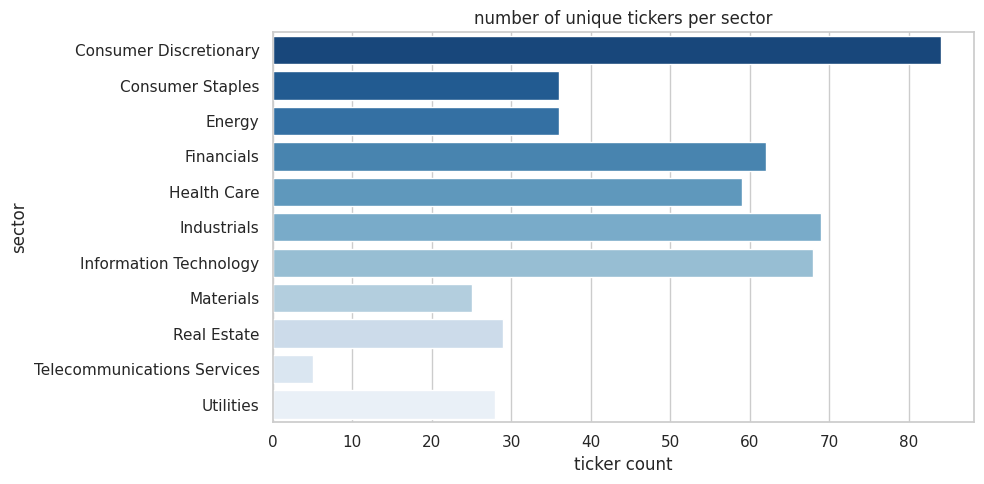

In [ ]:
# visualizing how many tickers fall into each sector
sector_counts = prices.groupby('sector')['symbol'].nunique().sort_values()

plt.figure(figsize=(10, 5))
sns.barplot(x=sector_counts.values, y=sector_counts.index, palette='Blues_r')
plt.title('number of unique tickers per sector')
plt.xlabel('ticker count')
plt.tight_layout()
plt.show()

In [ ]:
# computing indicators ticker by ticker to avoid memory spike
import pandas_ta as ta

def add_indicators(group):
    group = group.copy()
    group['ma10']      = group['close'].rolling(10).mean()
    group['ma30']      = group['close'].rolling(30).mean()
    group['ma50']      = group['close'].rolling(50).mean()
    group['rsi']       = ta.rsi(group['close'], length=14)
    group['vol_ratio'] = group['volume'] / group['volume'].rolling(20).mean()

    macd = ta.macd(group['close'], fast=12, slow=26, signal=9)
    bb   = ta.bbands(group['close'], length=20, std=2)

    group = pd.concat([
        group.reset_index(drop=True),
        macd.reset_index(drop=True),
        bb.reset_index(drop=True)
    ], axis=1)
    return group

print("computing indicators — processing ticker by ticker...")
tickers = prices['symbol'].unique()
chunks  = []

for i, ticker in enumerate(tickers):
    chunk = prices[prices['symbol'] == ticker].copy()
    chunk = add_indicators(chunk)
    chunks.append(chunk)
    if i % 100 == 0:
        print(f"  processed {i}/{len(tickers)} tickers...")

prices = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

print("done — shape:", prices.shape)

computing indicators — processing ticker by ticker...
  processed 0/501 tickers...
  processed 100/501 tickers...
  processed 200/501 tickers...
  processed 300/501 tickers...
  processed 400/501 tickers...
  processed 500/501 tickers...
done — shape: (851264, 21)


In [ ]:
# forward-filling fundamentals onto daily rows using a regular merge + ffill
# merge_asof requires global date sort which conflicts with groupby symbol sort

fundamentals['Period Ending'] = pd.to_datetime(fundamentals['Period Ending'])
fundamentals = fundamentals.rename(columns={'Ticker Symbol': 'symbol'})

# i merge fundamentals by year since they are annual
fundamentals['year'] = fundamentals['Period Ending'].dt.year
prices['year']       = prices['date'].dt.year

prices = prices.merge(
    fundamentals.drop(columns=['Period Ending']),
    on=['symbol', 'year'],
    how='left'
)

# dropping the year column after merge
prices = prices.drop(columns=['year'])

del fundamentals
gc.collect()

print("shape after merging fundamentals:", prices.shape)
print("\nnull counts:")
print(prices[['Earnings Per Share', 'Profit Margin', 'Current Ratio']].isnull().sum())

shape after merging fundamentals: (852272, 30)

null counts:
Earnings Per Share    462618
Profit Margin         413114
Current Ratio         485328
dtype: int64


In [ ]:
# forward-filling fundamental nulls within each ticker — carries last known value forward
fund_fill_cols = ['Earnings Per Share', 'Total Revenue', 'Net Income',
                  'Total Assets', 'Total Liabilities', 'Profit Margin',
                  'Total Equity', 'Operating Margin', 'Current Ratio']

prices = prices.sort_values(['symbol', 'date'])
prices[fund_fill_cols] = prices.groupby('symbol')[fund_fill_cols].ffill()

# dropping first 50 rows per ticker since indicators need history to be meaningful
prices = prices.groupby('symbol').apply(lambda x: x.iloc[50:]).reset_index(drop=True)

# dropping rows where key indicators are still null
key_cols = ['ma50', 'rsi', 'vol_ratio', 'MACD_12_26_9', 'BBU_20_2.0_2.0']
prices   = prices.dropna(subset=key_cols)

print("shape after cleanup:", prices.shape)
print("unique tickers remaining:", prices['symbol'].nunique())
print("\nfundamental null counts after ffill:")
print(prices[['Earnings Per Share', 'Profit Margin', 'Current Ratio']].isnull().sum())

shape after cleanup: (827222, 30)
unique tickers remaining: 501

fundamental null counts after ffill:
Earnings Per Share    347836
Profit Margin         328582
Current Ratio         415262
dtype: int64


/tmp/ipykernel_2875/42795157.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prices = prices.groupby('symbol').apply(lambda x: x.iloc[50:]).reset_index(drop=True)


In [ ]:
# creating next-day direction labels per ticker
# shifting by -1 so the label for day T is what happens on day T+1
# this is the most important correctness step — prevents data leakage

def make_label(pct):
    if pct > 0.01:  return 'Up'
    if pct < -0.01: return 'Down'
    return 'Neutral'

prices['next_day_return'] = prices.groupby('symbol')['close'].pct_change().shift(-1)
prices['label']           = prices['next_day_return'].apply(make_label)
prices                    = prices.dropna(subset=['next_day_return'])

print("label distribution:")
print(prices['label'].value_counts())
print("\nlabel percentages:")
print(prices['label'].value_counts(normalize=True).mul(100).round(1))

label distribution:
label
Neutral    468997
Up         188619
Down       169105
Name: count, dtype: int64

label percentages:
label
Neutral   56.70
Up        22.80
Down      20.50
Name: proportion, dtype: float64


/tmp/ipykernel_2875/2570084676.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values,


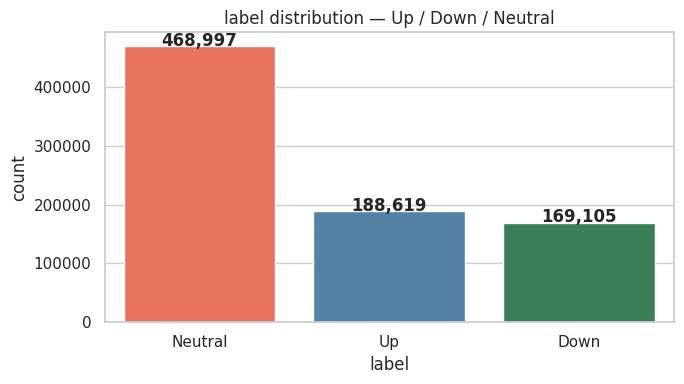

In [ ]:
# checking class balance — important for deciding whether to use SMOTE or class weighting
label_counts = prices['label'].value_counts()

plt.figure(figsize=(7, 4))
sns.barplot(x=label_counts.index, y=label_counts.values,
            palette=['tomato', 'steelblue', 'seagreen'])
plt.title('label distribution — Up / Down / Neutral')
plt.xlabel('label')
plt.ylabel('count')
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

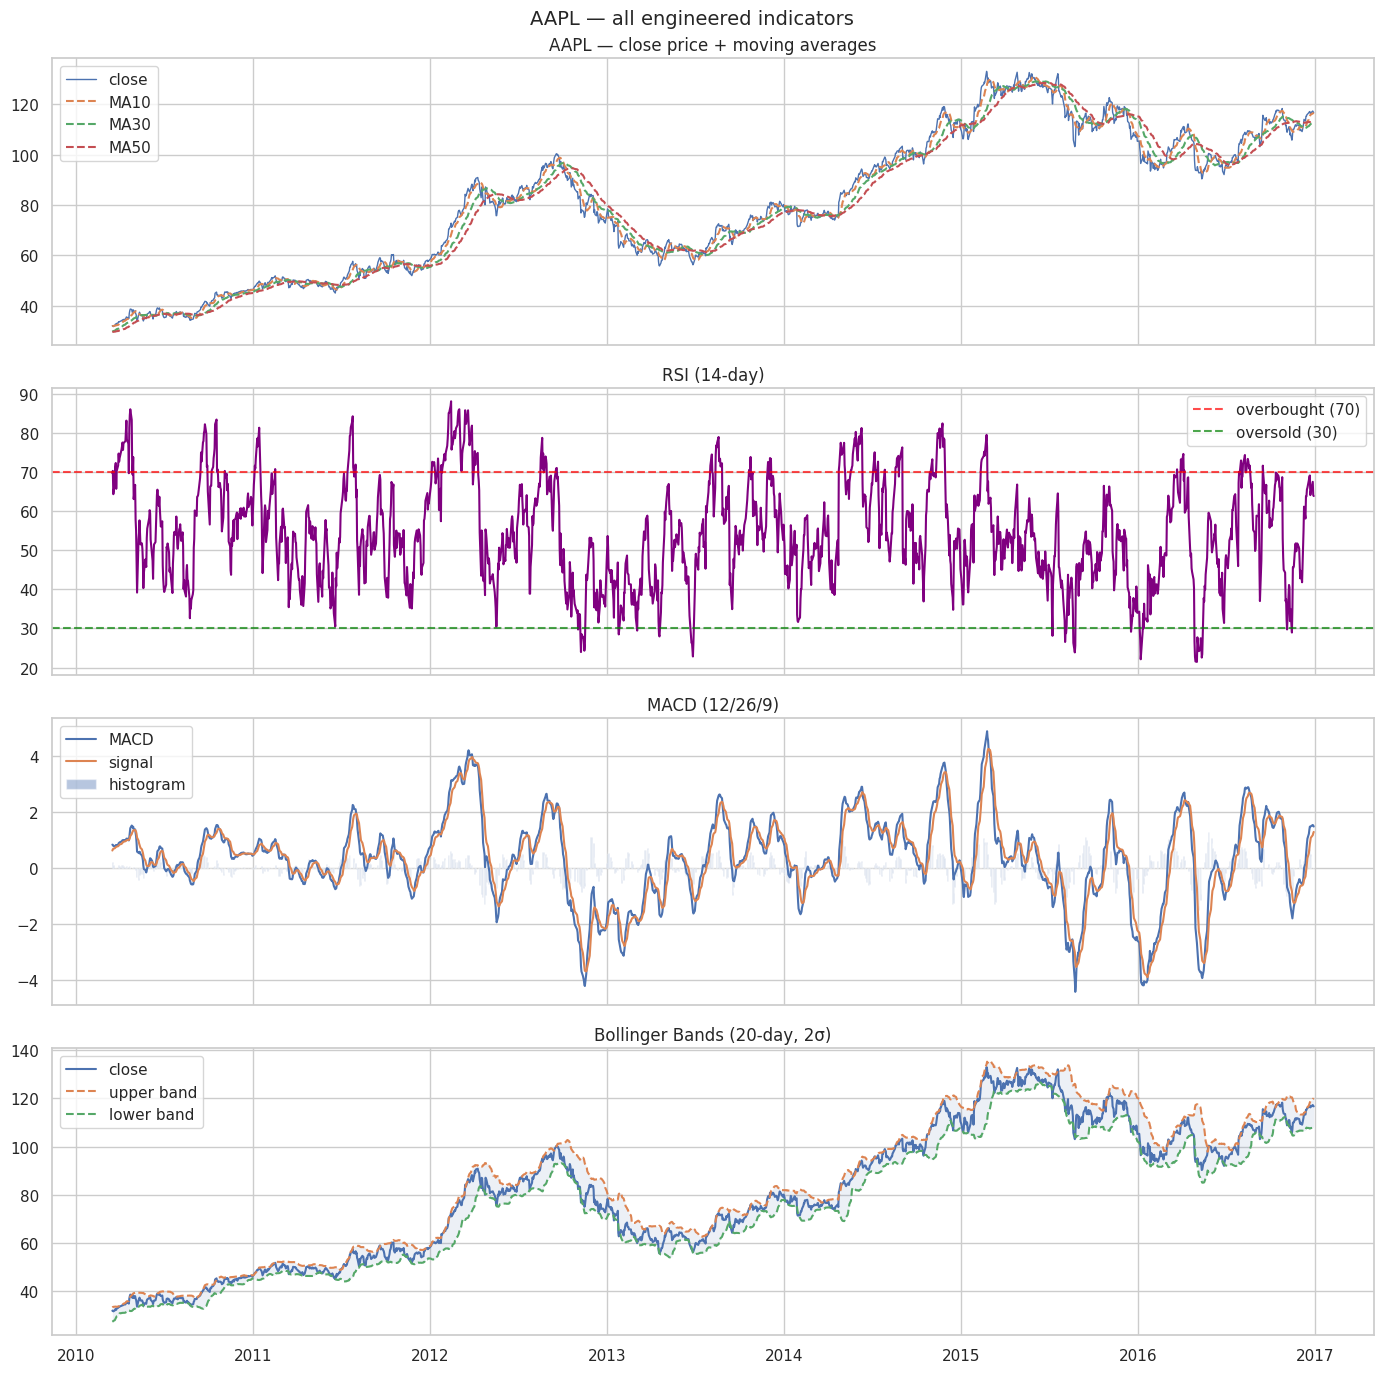

In [ ]:
# plotting all engineered indicators for AAPL to visually verify correctness
aapl = prices[prices['symbol'] == 'AAPL'].copy()

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# close price with moving averages
axes[0].plot(aapl['date'], aapl['close'], label='close', linewidth=1)
axes[0].plot(aapl['date'], aapl['ma10'],  label='MA10',  linestyle='--')
axes[0].plot(aapl['date'], aapl['ma30'],  label='MA30',  linestyle='--')
axes[0].plot(aapl['date'], aapl['ma50'],  label='MA50',  linestyle='--')
axes[0].set_title('AAPL — close price + moving averages')
axes[0].legend()

# RSI
axes[1].plot(aapl['date'], aapl['rsi'], color='purple')
axes[1].axhline(70, color='red',   linestyle='--', alpha=0.7, label='overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', alpha=0.7, label='oversold (30)')
axes[1].set_title('RSI (14-day)')
axes[1].legend()

# MACD
axes[2].plot(aapl['date'], aapl['MACD_12_26_9'],  label='MACD')
axes[2].plot(aapl['date'], aapl['MACDs_12_26_9'], label='signal')
axes[2].bar(aapl['date'],  aapl['MACDh_12_26_9'], label='histogram', alpha=0.4)
axes[2].set_title('MACD (12/26/9)')
axes[2].legend()

# Bollinger Bands — using actual column names from pandas_ta
axes[3].plot(aapl['date'], aapl['close'],           label='close')
axes[3].plot(aapl['date'], aapl['BBU_20_2.0_2.0'],  label='upper band', linestyle='--')
axes[3].plot(aapl['date'], aapl['BBL_20_2.0_2.0'],  label='lower band', linestyle='--')
axes[3].fill_between(aapl['date'], aapl['BBL_20_2.0_2.0'], aapl['BBU_20_2.0_2.0'], alpha=0.1)
axes[3].set_title('Bollinger Bands (20-day, 2σ)')
axes[3].legend()

plt.suptitle('AAPL — all engineered indicators', fontsize=14)
plt.tight_layout()
plt.show()

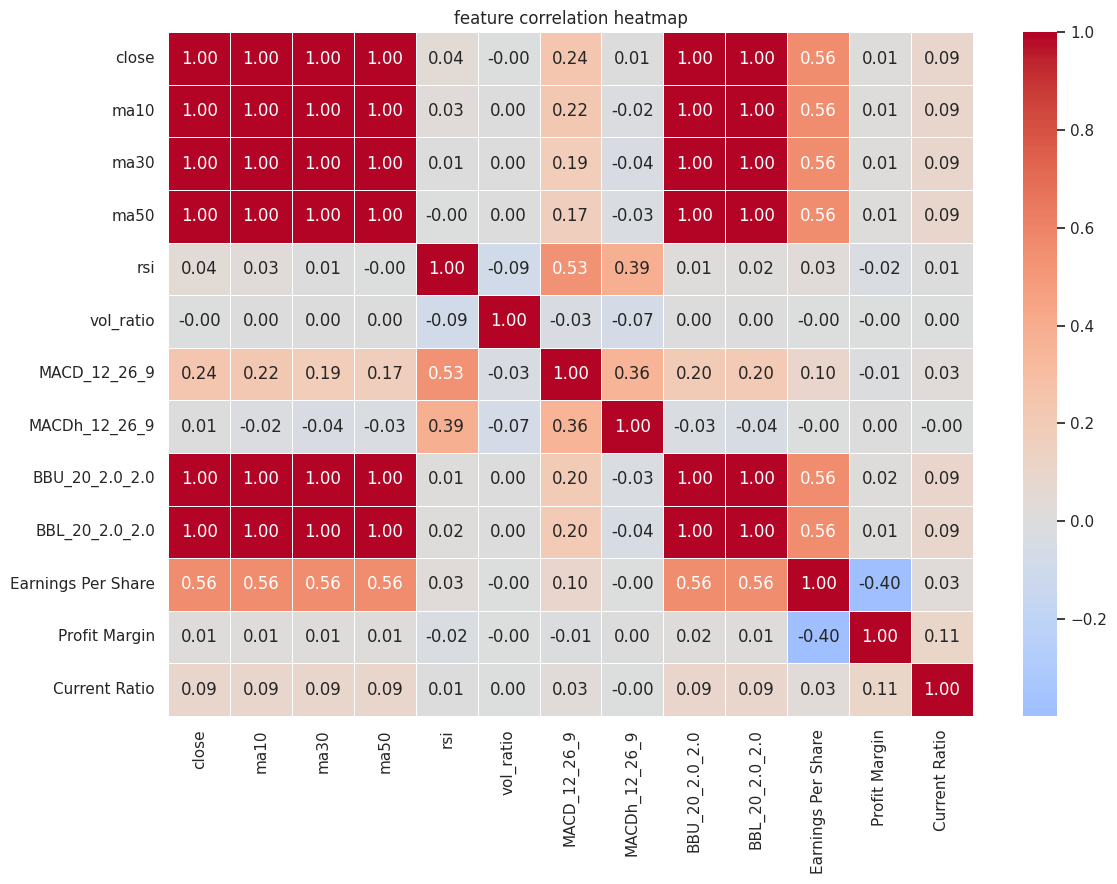

In [ ]:
feature_cols = ['close', 'ma10', 'ma30', 'ma50', 'rsi', 'vol_ratio',
                'MACD_12_26_9', 'MACDh_12_26_9', 'BBU_20_2.0_2.0', 'BBL_20_2.0_2.0',
                'Earnings Per Share', 'Profit Margin', 'Current Ratio']

corr = prices[feature_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('feature correlation heatmap')
plt.tight_layout()
plt.show()

In [ ]:
# splitting chronologically — never shuffle stock data
train = prices[prices['date'] < '2015-01-01']
val   = prices[(prices['date'] >= '2015-01-01') & (prices['date'] < '2016-01-01')]
test  = prices[prices['date'] >= '2016-01-01']

print("train:", train.shape, "| val:", val.shape, "| test:", test.shape)
print("\ntrain labels:\n", train['label'].value_counts(normalize=True).mul(100).round(1))
print("\nval labels:\n",   val['label'].value_counts(normalize=True).mul(100).round(1))
print("\ntest labels:\n",  test['label'].value_counts(normalize=True).mul(100).round(1))

# saving master dataframe and splits for use in later notebooks
prices.to_csv(data_path + 'master.csv', index=False)
train.to_csv(data_path + 'train.csv',   index=False)
val.to_csv(data_path + 'val.csv',       index=False)
test.to_csv(data_path + 'test.csv',     index=False)

print("\nsaved master.csv, train.csv, val.csv, test.csv ")

train: (575682, 32) | val: (124525, 32) | test: (126514, 32)

train labels:
 label
Neutral   56.80
Up        23.00
Down      20.20
Name: proportion, dtype: float64

val labels:
 label
Neutral   55.70
Down      22.30
Up        22.00
Name: proportion, dtype: float64

test labels:
 label
Neutral   57.50
Up        22.70
Down      19.80
Name: proportion, dtype: float64

saved master.csv, train.csv, val.csv, test.csv 


In [ ]:
import os
import json
from google.colab import drive, _message, userdata

# pulling credentials from colab secrets
github_token = userdata.get('GITHUB_TOKEN')
github_email = userdata.get('GITHUB_EMAIL')
github_name  = userdata.get('GITHUB_NAME')

# saving the notebook to google drive
notebook_name = '02_feature_engineering'
notebook_path = f'/content/drive/MyDrive/ML/stock-lens/notebooks/{notebook_name}.ipynb'

notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=120)
with open(notebook_path, 'w') as f:
    json.dump(notebook_json['ipynb'], f)
print("saved to drive")

# installing pdf conversion dependencies
os.system('apt-get install -y libatk1.0-0 libatk-bridge2.0-0 libcups2 libxkbcommon0 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libasound2 -q')
os.system('pip install -q nbconvert[webpdf] playwright')
os.system('playwright install chromium')

# converting notebook to pdf
os.system(f'jupyter nbconvert --to webpdf --allow-chromium-download "{notebook_path}"')
pdf_path = notebook_path.replace('.ipynb', '.pdf')
print("pdf created!!" if os.path.exists(pdf_path) else "pdf creation failed")

# cloning repo if not already present
repo_path = '/content/stock-lens'
if not os.path.exists(repo_path):
    os.system(f'git clone https://github.com/SidRoy97/stock-lens.git {repo_path}')

# creating notebooks folder if missing
os.makedirs(f'{repo_path}/notebooks', exist_ok=True)

# copying notebook and pdf into repo
os.system(f'cp "{notebook_path}" "{repo_path}/notebooks/{notebook_name}.ipynb"')
if os.path.exists(pdf_path):
    os.system(f'cp "{pdf_path}" "{repo_path}/notebooks/{notebook_name}.pdf"')

# configuring git with user credentials
os.system(f'git -C {repo_path} config user.email "{github_email}"')
os.system(f'git -C {repo_path} config user.name "{github_name}"')
os.system(f'git -C {repo_path} add notebooks/')

commit = os.popen(f'git -C {repo_path} commit -m "update {notebook_name} notebook and pdf" 2>&1').read()
print("commit:", commit)

# pushing to github
remote = f'https://{github_token}@github.com/SidRoy97/stock-lens.git'
push   = os.popen(f'git -C {repo_path} push {remote} main 2>&1').read()
print("push:", push)